解决了什么样大小的卷积核最合适的问题。

有时使用不同大小的卷积核组合是有利的。

Inception块

GoogleNet中基本的卷积块被称为Inception块。
Inception块由四条并行路径组成。

前三条路径使用窗口大小为$1\times 1$、$3\times 3$和$5\times 5$的卷积层，从不同空间大小中提取信息。
中间的两条路径在输入上执行$1\times 1$卷积，以减少通道数，从而降低模型的复杂性。
第四条路径使用$3\times 3$最大汇聚层，然后使用$1\times 1$卷积层来改变通道数。
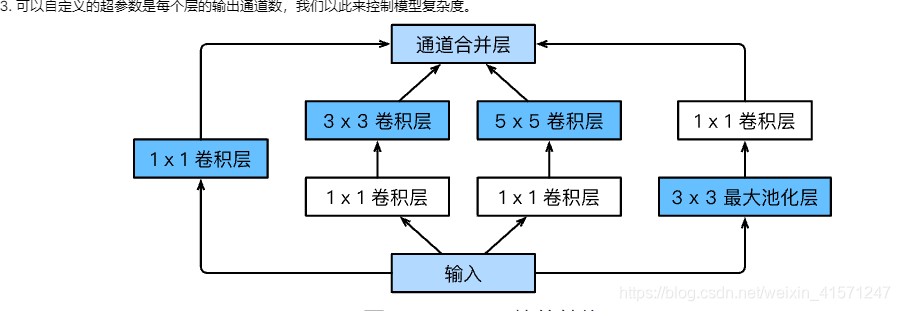

In [1]:
import torch
from torch import nn
from torch.nn import functional as F


class Inception(nn.Module):
    # c1--c4是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 线路1，单1x1卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        # 线路2，1x1卷积层后接3x3卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        # 线路3，1x1卷积层后接5x5卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        # 线路4，3x3最大汇聚层后接1x1卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        # 在通道维度上连结输出
        return torch.cat((p1, p2, p3, p4), dim=1)

GoogLeNet模型

GoogLeNet一共使用9个Inception块和全局平均汇聚层的堆叠来生成其估计值。Inception块之间的最大汇聚层可降低维度。
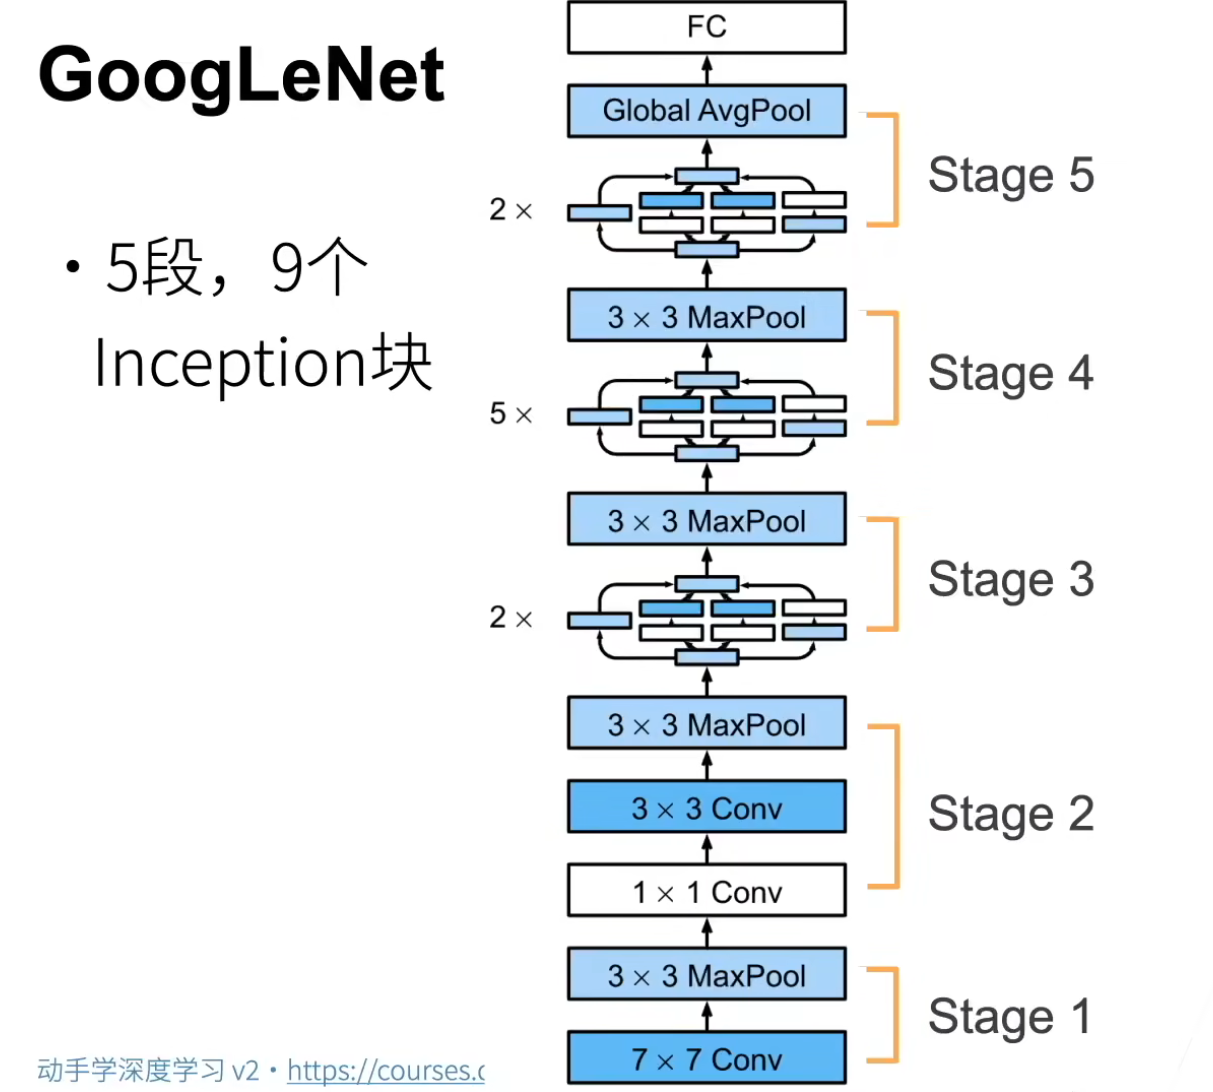

下面实现每个模块

第一个模块使用64个通道、$7\times 7$卷积层。


In [2]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第二个模块使用两个卷积层：第一个卷积层是64个通道、$1\times 1$卷积层；第二个卷积层使用将通道数量增加三倍的$3\times 3$卷积层。
这对应于Inception块中的第二条路径。


In [3]:
b2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=1),
                   nn.ReLU(),
                   nn.Conv2d(64, 192, kernel_size=3, padding=1),
                   nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第三个模块串联两个完整的Inception块。

In [4]:
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32),
                   Inception(256, 128, (128, 192), (32, 96), 64),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第四模块更加复杂， 它串联了5个Inception块。

In [5]:
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64),
                   Inception(512, 160, (112, 224), (24, 64), 64),
                   Inception(512, 128, (128, 256), (24, 64), 64),
                   Inception(512, 112, (144, 288), (32, 64), 64),
                   Inception(528, 256, (160, 320), (32, 128), 128),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

第五模块串联了两个Inception块，其后面紧跟输出层，该模块同NiN一样使用全局平均汇聚层，将每个通道的高和宽变成1

In [6]:
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128),
                   Inception(832, 384, (192, 384), (48, 128), 128),
                   nn.AdaptiveAvgPool2d((1,1)),
                   nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))

训练模型

In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time

# 超参数
lr, num_epochs, batch_size = 0.1, 10, 128

# 选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("training on", device)

# 数据预处理
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 下载数据集
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# 数据加载器
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 计算准确率
def evaluate_accuracy_gpu(net, data_iter, device):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += y.numel()
    return correct / total

# 参数初始化
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

net.apply(init_weights)

# 训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):

    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()
        metric_loss = 0.0
        metric_correct = 0
        metric_total = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric_loss += l.item() * X.shape[0]
            metric_correct += (y_hat.argmax(dim=1) == y).sum().item()
            metric_total += y.numel()

        train_loss = metric_loss / metric_total
        train_acc = metric_correct / metric_total
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f"epoch {epoch + 1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time() - start:.1f} sec")

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.26MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.6MB/s]


epoch 1, train loss 1.8200, train acc 0.3186, test acc 0.6603, time 15.2 sec
epoch 2, train loss 0.6212, train acc 0.7676, test acc 0.8112, time 13.4 sec
epoch 3, train loss 0.4387, train acc 0.8337, test acc 0.8408, time 13.3 sec
epoch 4, train loss 0.3727, train acc 0.8585, test acc 0.8546, time 13.5 sec
epoch 5, train loss 0.3333, train acc 0.8727, test acc 0.8693, time 13.4 sec
epoch 6, train loss 0.3045, train acc 0.8849, test acc 0.8736, time 13.4 sec
epoch 7, train loss 0.3822, train acc 0.8596, test acc 0.8607, time 13.5 sec
epoch 8, train loss 0.2986, train acc 0.8864, test acc 0.8541, time 13.5 sec
epoch 9, train loss 0.2583, train acc 0.9034, test acc 0.8910, time 13.4 sec
epoch 10, train loss 0.2408, train acc 0.9079, test acc 0.8970, time 13.3 sec


## 练习

1. GoogLeNet有一些后续版本。尝试实现并运行它们，然后观察实验结果。这些后续版本包括：
    * 添加批量规范化层 :cite:`Ioffe.Szegedy.2015`（batch normalization），在 :numref:`sec_batch_norm`中将介绍；
    * 对Inception模块进行调整 :cite:`Szegedy.Vanhoucke.Ioffe.ea.2016`；
    * 使用标签平滑（label smoothing）进行模型正则化 :cite:`Szegedy.Vanhoucke.Ioffe.ea.2016`；
    * 加入残差连接 :cite:`Szegedy.Ioffe.Vanhoucke.ea.2017`。（ :numref:`sec_resnet`将介绍）。


添加批量规范化层

In [8]:
import torch
from torch import nn

class InceptionBN(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4):
        super().__init__()
        self.p1 = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=1),
            nn.BatchNorm2d(c1),
            nn.ReLU()
        )

        self.p2 = nn.Sequential(
            nn.Conv2d(in_channels, c2[0], kernel_size=1),
            nn.BatchNorm2d(c2[0]),
            nn.ReLU(),
            nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1),
            nn.BatchNorm2d(c2[1]),
            nn.ReLU()
        )

        self.p3 = nn.Sequential(
            nn.Conv2d(in_channels, c3[0], kernel_size=1),
            nn.BatchNorm2d(c3[0]),
            nn.ReLU(),
            nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2),
            nn.BatchNorm2d(c3[1]),
            nn.ReLU()
        )

        self.p4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, c4, kernel_size=1),
            nn.BatchNorm2d(c4),
            nn.ReLU()
        )

    def forward(self, x):
        p1 = self.p1(x)
        p2 = self.p2(x)
        p3 = self.p3(x)
        p4 = self.p4(x)
        return torch.cat((p1, p2, p3, p4), dim=1)


class GoogLeNetBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.b3 = nn.Sequential(
            InceptionBN(192, 64, (96, 128), (16, 32), 32),
            InceptionBN(256, 128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.b4 = nn.Sequential(
            InceptionBN(480, 192, (96, 208), (16, 48), 64),
            InceptionBN(512, 160, (112, 224), (24, 64), 64),
            InceptionBN(512, 128, (128, 256), (24, 64), 64),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.classifier(x)
        return x


net = GoogLeNetBN()
net.apply(init_weights)

GoogLeNetBN(
  (b1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (b2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (b3): Sequential(
    (0): InceptionBN(
      (p1): Sequential(
        (0): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
   

In [9]:
lr, num_epochs, batch_size = 0.001, 10, 128

train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 1.4821, train acc 0.5186, test acc 0.7390, time 13.3 sec
epoch 2, train loss 0.8785, train acc 0.7204, test acc 0.7757, time 12.7 sec
epoch 3, train loss 0.7051, train acc 0.7609, test acc 0.7935, time 12.8 sec
epoch 4, train loss 0.6179, train acc 0.7871, test acc 0.8116, time 12.7 sec
epoch 5, train loss 0.5588, train acc 0.8070, test acc 0.8261, time 12.9 sec
epoch 6, train loss 0.5121, train acc 0.8241, test acc 0.8403, time 12.7 sec
epoch 7, train loss 0.4749, train acc 0.8360, test acc 0.8475, time 12.8 sec
epoch 8, train loss 0.4447, train acc 0.8467, test acc 0.8562, time 12.8 sec
epoch 9, train loss 0.4205, train acc 0.8542, test acc 0.8599, time 13.0 sec
epoch 10, train loss 0.3990, train acc 0.8605, test acc 0.8674, time 12.9 sec


lable smoothing

In [10]:
net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))
net.apply(init_weights)

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (2): Sequential(
    (0): Inception(
      (p1_1): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (p2_1): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
      (p2_2): Conv2d(96, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (p3_1): Conv2d(192, 16, kernel_size=(1, 1), stride=(1, 1))
      (p3_2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (p4_1): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
      (p4_2): Conv2d(192, 32, ker

In [11]:
# 训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss(label_smoothing=0.1)   # 如果做 label smoothing，后面改这一行

    for epoch in range(num_epochs):
        net.train()
        metric_loss = 0.0
        metric_correct = 0
        metric_total = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric_loss += l.item() * X.shape[0]
            metric_correct += (y_hat.argmax(dim=1) == y).sum().item()
            metric_total += y.numel()

        train_loss = metric_loss / metric_total
        train_acc = metric_correct / metric_total
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f"epoch {epoch + 1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time() - start:.1f} sec")

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 1.1473, train acc 0.6860, test acc 0.8294, time 13.9 sec
epoch 2, train loss 0.7816, train acc 0.8712, test acc 0.8897, time 13.6 sec
epoch 3, train loss 0.7213, train acc 0.8998, test acc 0.9026, time 13.7 sec
epoch 4, train loss 0.6935, train acc 0.9132, test acc 0.9124, time 13.6 sec
epoch 5, train loss 0.6743, train acc 0.9224, test acc 0.9100, time 13.7 sec
epoch 6, train loss 0.6596, train acc 0.9275, test acc 0.9149, time 13.9 sec
epoch 7, train loss 0.6487, train acc 0.9339, test acc 0.9131, time 13.7 sec
epoch 8, train loss 0.6372, train acc 0.9388, test acc 0.9200, time 13.7 sec
epoch 9, train loss 0.6249, train acc 0.9445, test acc 0.9209, time 13.6 sec
epoch 10, train loss 0.6185, train acc 0.9471, test acc 0.9224, time 13.7 sec


加入残差连接

In [14]:
class ResidualInceptionBN(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4):
        super().__init__()
        self.block = InceptionBN(in_channels, c1, c2, c3, c4)
        out_channels = c1 + c2[1] + c3[1] + c4
        self.proj = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + self.proj(x))

In [17]:
class GoogLeNetBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.b3 = nn.Sequential(
            InceptionBN(192, 64, (96, 128), (16, 32), 32),
            InceptionBN(256, 128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.b4 = nn.Sequential(
            ResidualInceptionBN(480, 192, (96, 208), (16, 48), 64),
            ResidualInceptionBN(512, 160, (112, 224), (24, 64), 64),
            ResidualInceptionBN(512, 128, (128, 256), (24, 64), 64),
            nn.AdaptiveAvgPool2d((1, 1))

        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.classifier(x)
        return x


net = GoogLeNetBN()
net.apply(init_weights)

GoogLeNetBN(
  (b1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (b2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (b3): Sequential(
    (0): InceptionBN(
      (p1): Sequential(
        (0): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
   

In [19]:
# 训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()   # 如果做 label smoothing，后面改这一行

    for epoch in range(num_epochs):
        net.train()
        metric_loss = 0.0
        metric_correct = 0
        metric_total = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric_loss += l.item() * X.shape[0]
            metric_correct += (y_hat.argmax(dim=1) == y).sum().item()
            metric_total += y.numel()

        train_loss = metric_loss / metric_total
        train_acc = metric_correct / metric_total
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f"epoch {epoch + 1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time() - start:.1f} sec")

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.4682, train acc 0.8380, test acc 0.8651, time 13.1 sec
epoch 2, train loss 0.2697, train acc 0.9021, test acc 0.8920, time 13.3 sec
epoch 3, train loss 0.2251, train acc 0.9173, test acc 0.9105, time 13.3 sec
epoch 4, train loss 0.1969, train acc 0.9267, test acc 0.9034, time 12.9 sec
epoch 5, train loss 0.1835, train acc 0.9332, test acc 0.9150, time 13.1 sec
epoch 6, train loss 0.1641, train acc 0.9396, test acc 0.9256, time 13.4 sec
epoch 7, train loss 0.1497, train acc 0.9452, test acc 0.9207, time 13.0 sec
epoch 8, train loss 0.1394, train acc 0.9489, test acc 0.9183, time 13.1 sec
epoch 9, train loss 0.1234, train acc 0.9550, test acc 0.9228, time 13.3 sec
epoch 10, train loss 0.1156, train acc 0.9570, test acc 0.9104, time 13.1 sec


1. 使用GoogLeNet的最小图像大小是多少？


GoogLeNet 通过多次步幅为2的卷积和池化操作对输入图像进行下采样，总体下采样倍数约为32。因此，为了保证最后的特征图尺寸不小于1×1，输入图像的最小尺寸应为32×32。在实际应用中，为了获得更稳定的训练效果，通常会使用64×64或96×96及以上的输入尺寸。

1. 将AlexNet、VGG和NiN的模型参数大小与GoogLeNet进行比较。后两个网络架构是如何显著减少模型参数大小的？

在模型参数量方面，AlexNet约为6000万参数，VGG-16约为1.38亿参数，而NiN约为750万，GoogLeNet约为500万，后两者显著减少了参数规模。

NiN通过使用多个1×1卷积层替代传统的全连接层，并结合全局平均池化，有效减少了参数数量。GoogLeNet则通过引入Inception模块，在网络中使用1×1卷积进行通道降维，并采用多分支结构提高特征表达能力，同时利用全局平均池化替代大规模全连接层，从而显著降低模型参数规模。